In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.read_csv("ab-test.csv")
print(df.shape)
df.sort_values("time", inplace=True)
df

(44, 4)


,uid,diff,time,group
0,user_1,-103.333333,after,test
26,user_22,-131.666667,after,control
30,user_26,-77.000000,after,control
24,user_20,-49.000000,after,control
22,user_2,-94.000000,after,control
42,user_8,-142.333333,after,control
20,user_16,17.500000,after,control
32,user_27,-9.000000,after,control
18,user_15,-32.000000,after,control
16,user_13,-81.500000,after,control


In [4]:
df_after = df.iloc[:22, :]
df_before = df.iloc[22:, :]

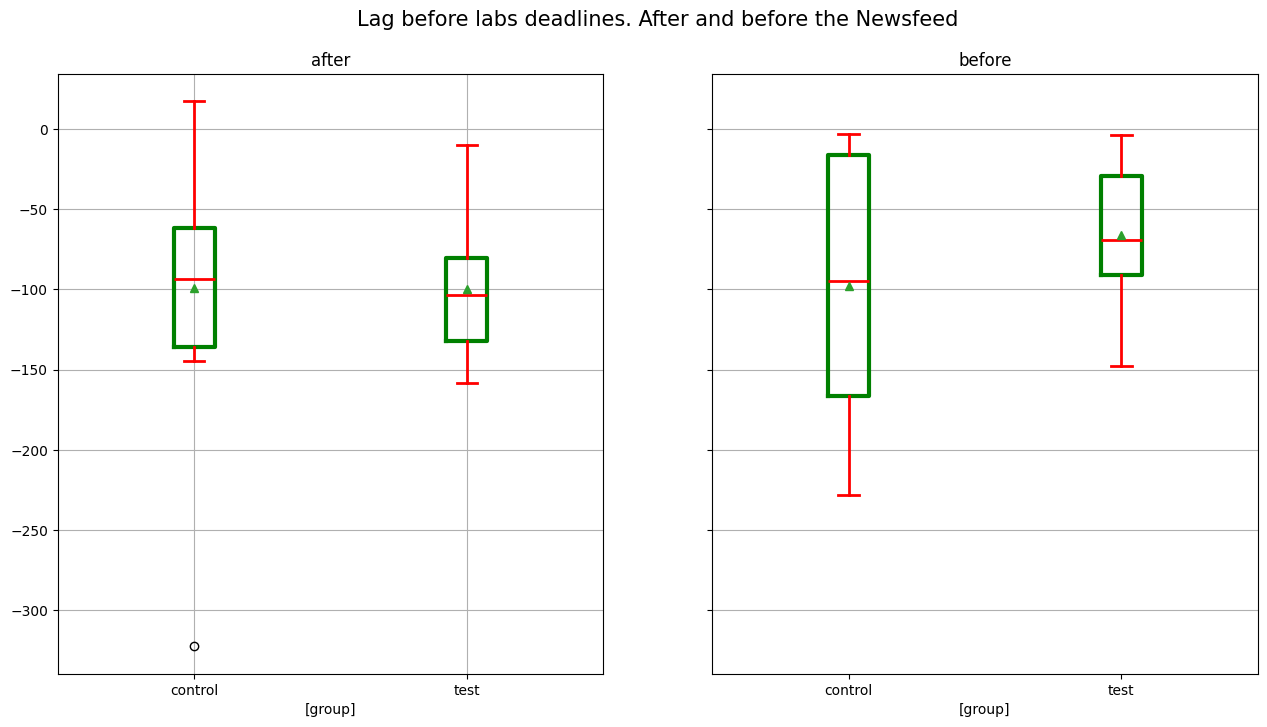

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

df_after.boxplot(ax=axes[0],
                 by="group",
                 widths=0.15,
                 boxprops=dict(linewidth=3, color='green'),
                 medianprops=dict(linewidth=2, color='red'),
                 whiskerprops=dict(linewidth=2, color='red'),
                 capprops=dict(linewidth=2, color='red'),
                 showmeans=True
)
axes[0].set_title("after")

df_before.boxplot(ax=axes[1],
                  by="group",
                  widths=0.15,
                  boxprops=dict(linewidth=3, color='green'),
                  medianprops=dict(linewidth=2, color='red'),
                  whiskerprops=dict(linewidth=2, color='red'),
                  capprops=dict(linewidth=2, color='red'),
                  showmeans=True
)
axes[1].set_title("before")


plt.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)
plt.grid(axis="x")
plt.show()

What was the IQR of the control group before the newsfeed? 150.

In [6]:
conn.close()